### Master of Applied Artificial Intelligence

**Course: TC5035 - Cuadro Inteligente**

<img src="../assets/logo.png" alt="Image Alt Text" width="500"/>


**Exploratory Data Analysis**

Tutor: Dr. Horario Martinez Alfaro


Team members:
* Ignacio Jose Aguilar Garcia - A00819762
* Alejandro Calderon Aguilar - A01795353
* Ricardo Mar Cupido - A01795394


¿Hay valores faltantes en el conjunto de datos? ¿Se pueden identificar patrones de ausencia? 
¿Cuáles son las estadísticas resumidas del conjunto de datos?
¿Hay valores atípicos en el conjunto de datos?
¿Existen distribuciones sesgadas en el conjunto de datos? ¿Necesitamos aplicar alguna transformación no lineal?
¿Hay correlación entre las variables dependientes e independientes?
¿Cómo se distribuyen los datos en función de diferentes categorías? (análisis bivariado)


# Import dependencies

In [1]:
import sys
sys.path.append('../../')

In [4]:
import importlib, scripts.model.plotting_helpers as ph, scripts.model.transformations as transformations
importlib.reload(ph)
importlib.reload(transformations)
from scripts.model.plotting_helpers import plot_target
from scripts.model.transformations import ModelTransformations
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


## 3.1 DF with selected features

In [10]:
selected_feats = '../../data/features/features.csv'
df = pd.read_csv(selected_feats)
df.head()

,state_name,previous_classification,previous_calls,client_age,network_age_years,banking,arpu_90_days,minutes_in,validity_average,average_performance,...,contacts,high_frequency_contacts,plan_postpaid,sn_banking,digital_index_mean,connected_days,charged_days,apps_days,music_gb,sale
0,JALAPA,NEW CLIENT,0,69.0,3.16,0,92.58,9.41,3.50,0.50,...,8,0.50,0.20,0.00,0.17,89,52,24,0.000,0
1,GUATEMALA,NEW CLIENT,0,28.0,3.90,1,214.18,27.93,20.23,0.46,...,8,0.63,0.67,1.00,0.00,91,91,0,5.946,0
2,ALTA VERAPAZ,NOT INTERESTED,2,44.0,12.88,1,107.76,11.33,4.24,0.60,...,87,0.41,0.22,0.34,0.00,91,83,6,0.298,0
3,CHIMALTENANGO,NOT INTERESTED,3,56.0,1.94,1,142.31,6.83,1.46,0.68,...,42,0.40,0.11,0.20,0.00,90,83,1,0.000,0
4,HUEHUETENANGO,NOT INTERESTED,6,45.0,13.37,0,128.51,224.85,23.25,0.98,...,95,0.48,0.21,0.79,1.00,89,89,0,0.142,0


In [47]:
df_minority = df[df['sale'] == 1]
df_majority = df[df['sale'] == 0]

In [ ]:
from sklearn.utils import resample 

df_majority_downsample = resample(df_majority, replace=False, n_samples=int(len(df_minority) * 1), random_state=42)



In [49]:
df_balanced = pd.concat([df_minority, df_majority_downsample])

In [51]:
df_balanced.shape

(57190, 21)

## 3.2 set X and y variables 

In [52]:
X = df_balanced.drop(columns='sale')
y = df_balanced['sale']

print(f'X: {X.shape}')
print(f'y: {y.shape}')

X: (57190, 20)
y: (57190,)


## 3.3 Set train and test datasets

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [54]:
print(f'X_train=> rows: {X_train.shape[0]} cols: {X_train.shape[1]}')
print(f'X_test=> rows: {X_test.shape[0]} cols: {X_test.shape[1]}')

X_train=> rows: 40033 cols: 20
X_test=> rows: 17157 cols: 20


### 3.3.1 Numerical variables selected

In [55]:
numerical_vars_selected = X_train.select_dtypes(include="number").columns.tolist()
print(f'selected numerical variables: {len(numerical_vars_selected)}')
print(numerical_vars_selected[:-1])

selected numerical variables: 18
['previous_calls', 'client_age', 'network_age_years', 'banking', 'arpu_90_days', 'minutes_in', 'validity_average', 'average_performance', 'start_using_months', 'contacts', 'high_frequency_contacts', 'plan_postpaid', 'sn_banking', 'digital_index_mean', 'connected_days', 'charged_days', 'apps_days']


### 3.3.2 Categorical variables selected

In [56]:
categorical_vars_selected = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'categorical variables: {len(categorical_vars_selected)}')
print(categorical_vars_selected)

categorical variables: 2
['state_name', 'previous_classification']


### 3.3.3  y_train distribution

the dataset is imbalanced: only 3.74% of the records correspond to sales (positive class), while 96.25% are non-sales (negative class)

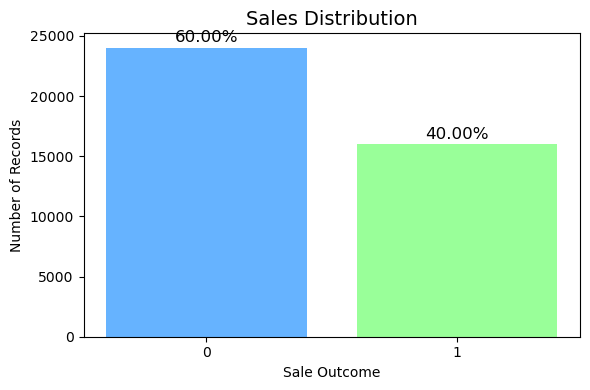

In [57]:
train_sales_counts = y_train.value_counts()
train_sales_perc = y_train.value_counts(normalize=True) * 100

plot_target(sales_counts=train_sales_counts, sales_perc=train_sales_perc)

# 3.4 Baseline Model

In [58]:
trans_feats = ModelTransformations()
preprocess = trans_feats.transform_pipeline_v1()

In [59]:
pos = np.sum(y_train == 1)
neg = np.sum(y_train == 0)
scale_pos_weight = neg / pos
print("scale_pos_weight =", scale_pos_weight)

scale_pos_weight = 1.500031224629988


In [60]:
import numpy as np
import pandas as pd

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import precision_recall_fscore_support,classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score

from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek


In [79]:
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    #("balance", SMOTE(sampling_strategy=0.3,random_state=42)),
    ("clf", XGBClassifier(
        # n_estimators=300,
        # max_depth=5,
        # learning_rate=0.05,
        # subsample=0.8,
        # colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,  # muy importante en desbalance
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    ))
])

In [80]:
clf.fit(X_train, y_train)

/Users/alejandrocalderon/anaconda3/lib/python3.11/site-packages/category_encoders/ordinal.py:209: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
/Users/alejandrocalderon/anaconda3/lib/python3.11/site-packages/category_encoders/ordinal.py:209: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are s

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('client_age',
                                                  Pipeline(steps=[('bounds',
                                                                   BoundsToNaN(lower=18,
                                                                               upper=80)),
                                                                  ('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log1p',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>))]),
                                                  ['client_age']),
                                                 ('start_using_months',
                                                  Pipeline(steps=[('bounds',
                                                                   BoundsToNaN(lower=0,
                                                                               upper=9...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=-1,
                               num_parallel_tree=None, random_state=42, ...))])

In [81]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

print("AUC:", roc_auc_score(y_test, y_proba))
print("F1 :", f1_score(y_test, y_pred))
print("Recall (Sensibilidad):", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

Confusion matrix:
[[6497 3797]
 [2899 3964]]

Classification report:
              precision    recall  f1-score   support

           0     0.6915    0.6311    0.6599     10294
           1     0.5108    0.5776    0.5421      6863

    accuracy                         0.6097     17157
   macro avg     0.6011    0.6044    0.6010     17157
weighted avg     0.6192    0.6097    0.6128     17157

AUC: 0.6429609152861291
F1 : 0.5421225382932167
Recall (Sensibilidad): 0.5775899752294915
Precision: 0.5107589228192243


/Users/alejandrocalderon/anaconda3/lib/python3.11/site-packages/category_encoders/ordinal.py:209: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
/Users/alejandrocalderon/anaconda3/lib/python3.11/site-packages/category_encoders/ordinal.py:209: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are s

array([[<Axes: title={'center': '0'}>]], dtype=object)

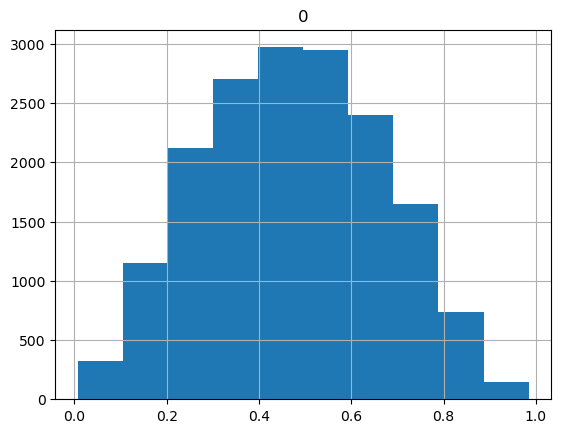

In [82]:
pd.DataFrame(y_proba).hist()

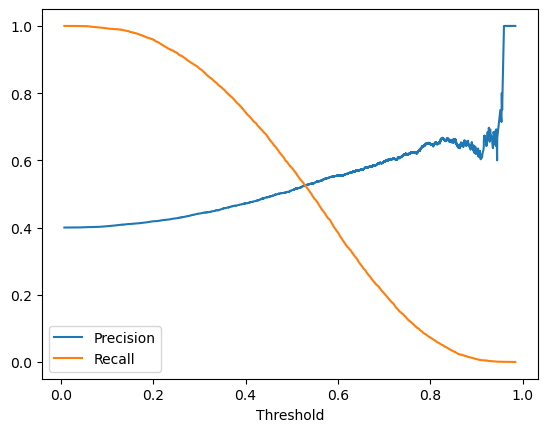

In [83]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, y_proba)

import matplotlib.pyplot as plt
plt.plot(thr, prec[:-1], label="Precision")
plt.plot(thr, rec[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [84]:
def threshold_iter(y, scores, min=0, max=1, step=0.1):
  if (min < 0):
    min = 0.0
  if (max > 1):
    max = 1.0
  if (not (min < step and step < max)):
    step = 0.1

  results = []
  for threshold in np.arange(min, max, step):
    result = threshold_truncate(y, scores, threshold)
    results.append(result)
  return results

def threshold_truncate(y, scores, threshold):
  prediction = (scores >= threshold).astype(int)
  precision, recall, f1, o = precision_recall_fscore_support(y, prediction, average='binary', labels=[1,0])
  tn, fp, fn, tp = confusion_matrix(y, prediction).ravel()
  result = {
      'threshold': threshold
      #, 'prediction': prediction
      , 'positive_prediction': prediction.mean()
      , 'precision': precision
      , 'recall': recall
      , 'f1': f1
      , 'support': o
      , 'tn': tn
      , 'fp': fp
      , 'fn': fn
      , 'tp': tp
  }
  return result


threshold_metrics = threshold_iter(y_test, y_proba, min=0, max=1, step=0.05)
threshold_metrics_df = pd.DataFrame(threshold_metrics)
threshold_metrics_df

,threshold,positive_prediction,precision,recall,f1,support,tn,fp,fn,tp
0,0.00,1.000000,0.400012,1.000000,0.571440,None,0,10294,0,6863
1,0.05,0.997261,0.400818,0.999271,0.572144,None,42,10252,5,6858
2,0.10,0.983272,0.403675,0.992277,0.573884,None,234,10060,53,6810
3,0.15,0.956985,0.410561,0.982224,0.579074,None,616,9678,122,6741
4,0.20,0.916302,0.418676,0.959056,0.582891,None,1155,9139,281,6582
5,0.25,0.861339,0.427595,0.920734,0.583984,None,1835,8459,544,6319
6,0.30,0.790698,0.441692,0.873088,0.586617,None,2720,7574,871,5992
7,0.35,0.713586,0.456097,0.813638,0.584528,None,3635,6659,1279,5584
8,0.40,0.629714,0.471862,0.742824,0.577121,None,4588,5706,1765,5098
9,0.45,0.541878,0.491341,0.665598,0.565347,None,5565,4729,2295,4568


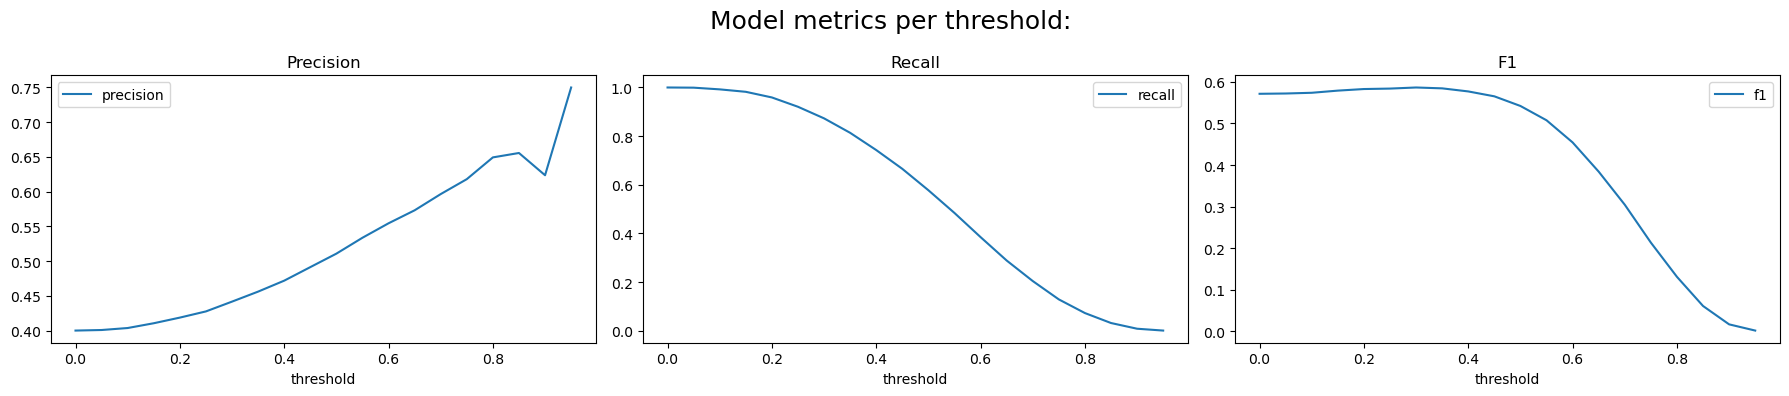

In [85]:
def plot_threshold_metrics(df):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,4))
    fig.suptitle('Model metrics per threshold: ', fontsize=18)

    # Precision
    df.plot(x='threshold', y=['precision'], ax=axes[0])
    axes[0].set_title('Precision')

    # Precision
    df.plot(x='threshold', y=['recall'], ax=axes[1])
    axes[1].set_title('Recall')

    # Precision
    df.plot(x='threshold', y=['f1'], ax=axes[2])
    axes[2].set_title('F1')

    plt.tight_layout()

plot_threshold_metrics(threshold_metrics_df)

In [86]:
y_pred_2 = (y_proba >= 0.5).astype(int)
print(confusion_matrix(y_test, y_pred_2))
print(classification_report(y_test, y_pred_2))

[[6497 3797]
 [2899 3964]]
              precision    recall  f1-score   support

           0       0.69      0.63      0.66     10294
           1       0.51      0.58      0.54      6863

    accuracy                           0.61     17157
   macro avg       0.60      0.60      0.60     17157
weighted avg       0.62      0.61      0.61     17157



## 4.1 Conclusion

In conclusion, a **regularized logistic regression** and a **single shallow tree** were considered as minimal baselines, but a **shallow XGBoost (max_depth≈2)** was adopted as the practical reference baseline because it consistently captures non-linear cutoffs and interactions in mixed tabular data without operational overhead. This confirms the problem is learnable: post-processing (truncation, targeted imputation, Quantile/Yeo-Johnson) stabilizes distributions, and class handling (under-sampling + threshold sweeps) yields separability above random.

Feature importance is **reliably determined with tree SHAP**, which provides faithful local and global attributions; the ranking by mean |SHAP| highlights spend/usage, banking/digital adoption, tenure/recency, prior call outcome, and social graph—guiding the removal or deprioritization of low-signal features. There is no evidence of material under/overfitting: shallow depth and regularization constrain variance, SHAP narratives remain stable across samples, and precision–recall curves are smooth; a parity check between SHAP-reconstructed probabilities and model outputs shows negligible deviation, reinforcing trust in the explanations.

Meeting these bars, the model is suitable for monthly batch scoring and for generating per-customer sales scripts grounded in transparent SHAP evidence.